<br>

<img src="https://lindas.admin.ch/static-assets/img/lindaslogo.png" style="width:25%; float:right">

# Tutorial SSZ

Dieses Notebook dient dazu, die RDF/Linked Data von SSZ besser zu verstehen, um die Daten kompetent nutzen zu können. Es ist **keine Einleitung** - weder in Linked Data noch in SPARQL. Wer die technischen Informationen und Voraussetzungen zu Beginn überspringen möchte, kann direkt zum eigentlichen [Tutorial](#Tutorial) springen.


# Introduction

The webpage you are currently viewing is a so called **interactive JupyterLite notebook**. In this notebook, you can change interactively the content of the single cells and execute these cells directly seeing the result of your changes immediately. The cells contain either [Markdown](https://en.wikipedia.org/wiki/Markdown) content (like this cell) or executable Python source code.

JupyterLite stems from JupyterLab with the advantage of being completely browser based without any backend infrastructure. This means that the execution of the cells could take some time during first execution. Subsequent executions will be much faster because of stored data in your browser cache.

If you are unfamiliar with the handling of Jupyter notebooks, here are two useful resources:

- [The JupyterLab Interface](https://jupyterlab.readthedocs.io/en/stable/user/interface.html)
- [The Jupyter Notebook](https://jupyterlab.readthedocs.io/en/stable/user/notebook.html)

# Preliminaries

In this part some preliminaries for querying LINDAS with SPARQL are introduced. If you are only interested in the actual LINDAS tutorial, you can skip the whole section and start [here](#Actual-Tutorial).

## Install and Import the Necessary Modules

Querying a SPARQL endpoint is basically making a POST request to the corresponding endpoint URL. As JupyterLite at the moment has no support for Python's `requests` modul, the JavaScript fetch API is used (with some tricks). To make this happen, the following modules have to be importet: 

In [23]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyodide.ffi import to_js
from IPython.display import JSON, HTML
from js import Object, fetch
from io import StringIO

## Define Main Query Function

As the JavaScript fetch API is asynchronous, the corresponding Python function `query` has to be declared as `async`. This function allows to query the 3 Swiss governmental triple stores.

In [2]:
async def query(query_string, store = "L"):
    
    # three Swiss triplestores
    if store == "F":
        address = 'https://fedlex.data.admin.ch/sparqlendpoint'
    elif store == "G":
        address = 'https://geo.ld.admin.ch/query'
    else:
        address = 'https://ld.admin.ch/query'
    
    # try the Post request with help of JS fetch
    # the creation of the request header is a little bit complicated because it needs to be a 
    # JavaScript JSON that is made within a Python source code
    try:
        resp = await fetch(address,
          method="POST",
          body="query=" + query_string,
          credentials="same-origin",
          headers=Object.fromEntries(to_js({"Content-Type": "application/x-www-form-urlencoded; charset=UTF-8", 
                                            "Accept": "text/csv" })),
        )
    except:
        raise RuntimeError("fetch failed")
    
    
    if resp.ok:
        res = await resp.text()
        # ld.admin.ch throws errors starting with '{"message":'
        if '{"message":' in res:
            error = json.loads(res)
            raise RuntimeError("SPARQL query malformed: " + error["message"])
        # geo.ld.admin.ch throws errors starting with 'Parse error:'
        elif 'Parse error:' in res:
            raise RuntimeError("SPARQL query malformed: " + res)
        else:
            # if everything works out, create a pandas dataframe from the csv result
            df = pd.read_csv(StringIO(res))
            return df
    else:
        # fedlex.data.admin.ch throws error with response status 400
        if resp.status == 400:
            raise RuntimeError("Response status 400: Possible malformed SPARQL query. No syntactic advice available.")
        else:
            raise RuntimeError("Response status " + resp.status)

If you are interested in the details of using the JavaScript fetch API within JupyterLite, please consult:

- https://pyodide.org/en/stable/usage/faq.html#how-can-i-use-fetch-with-optional-arguments-from-python
- https://github.com/jupyterlite/jupyterlite/discussions/412
- https://lwebapp.com/en/post/pyodide-fetch

## Define Display Function

Displays pandas dataframe resulting from the SPARQL query as HTML with clickable links.

In [3]:
def display_result(df):
    df = HTML(df.to_html(render_links=True, escape=False))
    display(df)

# Tutorial

## Cubes von SSZ

Der Datenkatalog mit allen Datasets ist über den Einstieg über https://ld.stadt-zuerich.ch/.well-known/void nach https://ld.stadt-zuerich.ch/catalog/SSZ/cube zu finden. Alle Daten von SSZ sind im Namedgraph https://lindas.admin.ch/stadtzuerich/stat abgelegt. Folgende Query liefert alle [RDF Cubes](https://cube.link) mit ihrem jeweiligen Namen:  

In [4]:
df = await query("""

PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX cube: <https://cube.link/>

SELECT * 
FROM <https://lindas.admin.ch/stadtzuerich/stat> #query only the namedgraph of SSZ data
WHERE {

    ?cube a cube:Cube;
        schema:name ?name
}

""")

display_result(df)

,cube,name
0,https://ld.stadt-zuerich.ch/statistics/000201,Wirtschaftliche Bevölkerung
1,https://ld.stadt-zuerich.ch/statistics/000181,"Wohnfläche in m2 (netto, exkl. leerstehende Wohnunben) pro Person"
2,https://ld.stadt-zuerich.ch/statistics/000202,Wirtschaftliche Bevölkerung nach Herkunft
3,https://ld.stadt-zuerich.ch/statistics/000205,Wirtschaftliche Bevölkerung nach Herkunft 2010 bis 2015 nach Stadtkreisen
4,https://ld.stadt-zuerich.ch/statistics/000203,Wirtschaftliche Bevölkerung nach Geschlecht
5,https://ld.stadt-zuerich.ch/statistics/000204,Wirtschaftliche Bevölkerung nach Herkunft und Geschlecht
6,https://ld.stadt-zuerich.ch/statistics/000206,Wirtschaftliche Bevölkerung nach 1-Jahresaltersklasse ab 1993
7,https://ld.stadt-zuerich.ch/statistics/000207,Wirtschaftliche Bevölkerung nach 5-Jahresaltersklasse ab 1993
8,https://ld.stadt-zuerich.ch/statistics/000249,Wirtschaftliche Bevölkerung nach 5-Jahresaltersklasse
9,https://ld.stadt-zuerich.ch/statistics/000208,Wirtschaftliche Bevölkerung nach 1-Jahresaltersklasse und Geschlecht


## Cube Wirtschaftliche Bevölkerung

### Raumgliederung über die Zeit

Folgende SPARQL Query zeigt auf, wie die Raumaufteilung der Stadt Zürich sich über die Jahre verändert hat. Es sollen also für jeden Zeitpunkt, an dem Daten zur wirtschaftlichen Bevölkerung vorliegen, die verwendeten Gliederungen aufgezeigt werden. Achtung, diese Gliederung beinhaltet auch Summationen von Gliederungen:

In [20]:
df = await query("""

PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX cube: <https://cube.link/>
PREFIX ssz: <https://ld.stadt-zuerich.ch/statistics/>

SELECT ?TIME (GROUP_CONCAT(?raum; separator=", ") AS ?raeume) (COUNT(?RAUM) AS ?number)
FROM <https://lindas.admin.ch/stadtzuerich/stat> #query only the namedgraph of SSZ data
WHERE {

    <https://ld.stadt-zuerich.ch/statistics/000201> cube:observationSet ?obsSet.
    ?obsSet cube:observation ?obs.
    ?obs ssz:property\/RAUM ?RAUM;
        ssz:measure\/BEW ?BEW;
        ssz:property\/TIME ?TIME.
    ?RAUM schema:name ?raum
        
    FILTER(?BEW != "NaN"^^xsd:double) #consider only observations that have a number for ?BEW
    
} GROUP BY ?TIME
ORDER BY ?TIME

""")

display_result(df)

,TIME,raeume,number
0,1408-12-31,Kreis 1 (Stadtgebiet vor 1893),1
1,1467-12-31,Kreis 1 (Stadtgebiet vor 1893),1
2,1529-12-31,Kreis 1 (Stadtgebiet vor 1893),1
3,1637-12-31,Kreis 1 (Stadtgebiet vor 1893),1
4,1671-12-31,Kreis 1 (Stadtgebiet vor 1893),1
5,1682-12-31,Kreis 1 (Stadtgebiet vor 1893),1
6,1762-12-31,Kreis 1 (Stadtgebiet vor 1893),1
7,1771-12-31,Kreis 1 (Stadtgebiet vor 1893),1
8,1792-12-31,Kreis 1 (Stadtgebiet vor 1893),1
9,1799-12-31,Kreis 1 (Stadtgebiet vor 1893),1


### Alle Räume

In [17]:
df = await query("""

PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX cube: <https://cube.link/>
PREFIX ssz: <https://ld.stadt-zuerich.ch/statistics/>

SELECT DISTINCT ?RAUM ?name
FROM <https://lindas.admin.ch/stadtzuerich/stat> #query only the namedgraph of SSZ data
WHERE {

    <https://ld.stadt-zuerich.ch/statistics/000201> cube:observationSet ?obsSet.
    ?obsSet cube:observation ?obs.
    ?obs ssz:property\/RAUM ?RAUM.
    ?RAUM schema:name ?name.
          
} 

""")

display_result(df)

,RAUM,name
0,https://ld.stadt-zuerich.ch/statistics/code/R00700,Kreis 4 (ab 1915)
1,https://ld.stadt-zuerich.ch/statistics/code/R00041,Werd
2,https://ld.stadt-zuerich.ch/statistics/code/R00042,Langstrasse
3,https://ld.stadt-zuerich.ch/statistics/code/R00044,Hard
4,https://ld.stadt-zuerich.ch/statistics/code/R01500,Kreis 10 (ab 1934)
5,https://ld.stadt-zuerich.ch/statistics/code/R10000,Kreis 1 (Stadtgebiet vor 1893)
6,https://ld.stadt-zuerich.ch/statistics/code/R00800,Kreis 5 (ab 1915)
7,https://ld.stadt-zuerich.ch/statistics/code/R01800,Kreis 11 (ab 1970)
8,https://ld.stadt-zuerich.ch/statistics/code/R01100,Kreis 8 (ab 1915)
9,https://ld.stadt-zuerich.ch/statistics/code/R01300,Kreis 7 (ab 1934)


### Naive Summation über alle Räume pro Zeit

In [13]:
df = await query("""

PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX cube: <https://cube.link/>
PREFIX ssz: <https://ld.stadt-zuerich.ch/statistics/>

SELECT ?TIME (SUM(?BEW) as ?pop)
FROM <https://lindas.admin.ch/stadtzuerich/stat> #query only the namedgraph of SSZ data
WHERE {

    <https://ld.stadt-zuerich.ch/statistics/000201> cube:observationSet ?obsSet.
    ?obsSet cube:observation ?obs.
    ?obs ssz:property\/RAUM ?RAUM;
        ssz:measure\/BEW ?BEW;
        ssz:property\/TIME ?TIME.
        
    FILTER(?BEW != "NaN"^^xsd:double)
    
} GROUP BY ?TIME
ORDER BY ?TIME

""")

display_result(df)

,TIME,pop
0,1408-12-31,5675.0
1,1467-12-31,4750.0
2,1529-12-31,5080.0
3,1637-12-31,8621.0
4,1671-12-31,9590.0
5,1682-12-31,11110.0
6,1762-12-31,11452.0
7,1771-12-31,10574.0
8,1792-12-31,10734.0
9,1799-12-31,10000.0


### Nur Stadträume

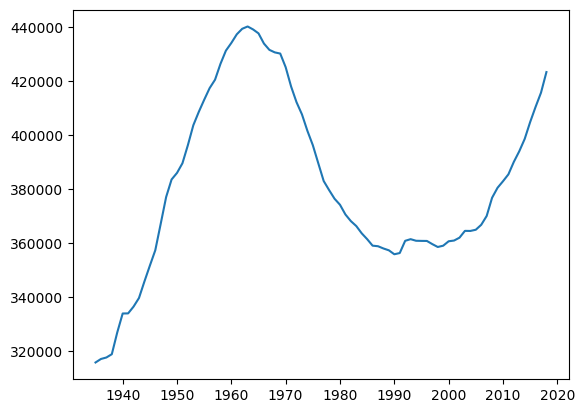

In [29]:
df = await query("""

PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX cube: <https://cube.link/>
PREFIX ssz: <https://ld.stadt-zuerich.ch/statistics/>

SELECT ?TIME (SUM(?BEW) as ?pop)
FROM <https://lindas.admin.ch/stadtzuerich/stat> #query only the namedgraph of SSZ data
WHERE {

    <https://ld.stadt-zuerich.ch/statistics/000201> cube:observationSet ?obsSet.
    ?obsSet cube:observation ?obs.
    ?obs ssz:property\/RAUM ?RAUM;
        ssz:measure\/BEW ?BEW;
        ssz:property\/TIME ?TIME.
        
    FILTER(?BEW != "NaN"^^xsd:double)
    FILTER(?RAUM = <https://ld.stadt-zuerich.ch/statistics/code/R30000>)
    
} GROUP BY ?TIME
ORDER BY ?TIME

""")

#display_result(df)

df["TIME"] = pd.to_datetime(df["TIME"])

plt.plot(df["TIME"], df["pop"]);

plt.show()

# Fragen

* wie kann man über das jeweilige gesamte Stadtgebiet aggregieren? --> schwierig
* es scheint, dass ab 2018 im Cube https://ld.stadt-zuerich.ch/statistics/000201 (Wirtschaftliche Bevölkerung) keine aggregierten Daten mehr für die Stadt (R30000) vorhanden sind --> Daten vor 2018 sind im Nachhinein in die HDB integriert worden und dort besteht eine gewisse Unordnung, ab 2018 ist es in Ordnung, aber es gibt im Moment in LINDAS keine Aggregierungen über die Quartiere hinaus